In [1]:
# importing libraries
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('https://raw.githubusercontent.com/thamidu02/AIML_project/refs/heads/main/data/balanced_data.csv')

In [3]:
data_df=pd.DataFrame(data)

In [4]:
data_df.head()

,age,height,weight,bmi,waist_size,blood_pressure,glucose,heart_rate,insulin,cholesterol,...,stress_level,target,gender_Female,gender_Male,job_type_Healthcare,job_type_Labor,job_type_Office,job_type_Service,job_type_Tech,job_type_Unemployed
0,-0.516129,0.532513,-0.286205,-0.466182,-0.793095,-0.048494,-0.789323,-0.065063,1.116397,-0.901466,...,0.500000,healthy,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.451613,0.113444,0.428740,0.317736,0.882447,-0.423962,-0.704292,0.462630,-1.300426,0.015120,...,0.500000,healthy,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.193548,0.138622,-0.039458,-0.095566,0.390318,0.780589,0.265728,0.034614,-0.527712,-0.439868,...,0.833333,healthy,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.903226,1.063068,0.538649,-0.046443,0.080632,-1.164706,1.604822,-0.305074,0.264342,-1.125651,...,0.666667,healthy,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.483871,0.117415,0.888653,0.710070,0.229271,0.296010,0.186589,-0.014294,0.462007,-1.840230,...,-0.333333,healthy,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [5]:
data_df.columns

Index(['age', 'height', 'weight', 'bmi', 'waist_size', 'blood_pressure',
       'glucose', 'heart_rate', 'insulin', 'cholesterol', 'sugar_intake',
       'daily_steps', 'calorie_intake', 'daily_supplement_dosage',
       'water_intake', 'income', 'work_hours', 'sleep_hours',
       'work_sleep_balance', 'stress_level', 'target', 'gender_Female',
       'gender_Male', 'job_type_Healthcare', 'job_type_Labor',
       'job_type_Office', 'job_type_Service', 'job_type_Tech',
       'job_type_Unemployed'],
      dtype='object')

In [6]:
data_df.describe()

,age,height,weight,bmi,waist_size,blood_pressure,glucose,heart_rate,insulin,cholesterol,...,work_sleep_balance,stress_level,gender_Female,gender_Male,job_type_Healthcare,job_type_Labor,job_type_Office,job_type_Service,job_type_Tech,job_type_Unemployed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.003823,0.014309,0.032780,0.060644,0.020136,-0.012667,0.047228,-0.032690,-0.005951,0.003951,...,0.127052,0.003833,0.507500,0.492500,0.169500,0.173500,0.158500,0.159500,0.173000,0.166000
std,0.579284,0.744236,0.726317,0.754748,0.748494,0.766680,0.732374,0.808740,0.793466,0.729208,...,0.821018,0.523859,0.500069,0.500069,0.375287,0.378774,0.365301,0.366233,0.378342,0.372174
min,-0.967742,-2.155411,-1.488155,-1.665177,-2.494987,-2.878071,-2.300899,-2.939604,-2.204649,-2.315525,...,-1.997276,-0.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.483871,-0.491521,-0.458288,-0.475792,-0.499730,-0.547553,-0.461426,-0.531622,-0.531502,-0.481871,...,-0.434426,-0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.009024,0.041447,0.040722,0.033636,0.002023,0.050934,-0.012009,0.003476,0.022496,...,0.018831,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.516129,0.504253,0.517436,0.545119,0.538444,0.507939,0.536331,0.473686,0.505658,0.495660,...,0.527461,0.500000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,2.585270,2.945759,3.127637,2.701138,2.501723,2.434811,2.967024,2.254904,3.201732,...,5.145421,0.833333,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
len(data_df.columns)

29

In [8]:
# splitting the target variable and input data
X,y=data_df.drop('target',axis=1),data_df['target']

In [9]:
data_df.target.value_counts()

,count
target,
healthy,1000
diseased,1000


In [10]:
# encoding the target variable
y=np.where(y=='healthy',1,0)

In [11]:
# splitting into train set and test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)

## Random Forest

A random forest is basically collection (ensemble) of many Decision Trees working together.Each tree gives its own prediction, and the forest takes a vote(for classification) or average (for regression)

so instead of trusting one tree, Random Forest combines the wisdom of many.

A single decision tree is:
*  Easy to understand
* But very sensitive - small changes in data can change the whole structture

Random Forest fixes that by:
* Combiningn many slightly different trees to make one strong,stable model.

------------


**How Random Forest Works**


1. Boostrap sampling(Random Data)

    For each tree, the algorithm takes a random sample (with replacement) of the training data.

    This means:
    * Each trees a slightly different dataset.
    * Some rows may appear more than once, some not at all
    
    This helps reduce overfitting


2. Random Feature Selection

    When splitting a node (choosing which feature to split on), the tree doesn’t consider all features, only a random subset.

    This ensures trees are diverse - they don't all make the same decision


**Important Parameters**
| Parameter             | Description                              | Effect                                     |
| --------------------- | ---------------------------------------- | ------------------------------------------ |
| **n_estimators**      | Number of trees in the forest            | More trees → better performance but slower |
| **max_depth**         | Maximum depth of each tree               | Prevents overfitting                       |
| **max_features**      | Number of features considered per split  | Controls randomness and diversity          |
| **min_samples_split** | Minimum samples to split a node          | Prevents overly complex trees              |
| **random_state**      | Random seed (for reproducibility)        | Same result every time                     |
| **criterion**         | ‘gini’ or ‘entropy’ (for classification) | Defines how splits are chosen              |


In [12]:
# importing random forest from sklearn
from sklearn.ensemble import RandomForestClassifier

In [13]:
# importing grid search
from sklearn.model_selection import GridSearchCV

In [14]:
param_grid=[
    {
        'n_estimators':[80,100],
        'max_depth':[3,4,5],
        'max_features':[5,8],
        'random_state':[42],
        'criterion':['gini']
    }
]

In [15]:
grid_search=GridSearchCV(RandomForestClassifier(),param_grid,cv=5)
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid=[{'criterion': ['gini'], 'max_depth': [3, 4, 5],
                          'max_features': [5, 8], 'n_estimators': [80, 100],
                          'random_state': [42]}])

In [16]:
print(f"Best cross validation score: {grid_search.best_score_}")

Best cross validation score: 0.48375


In [17]:
print(f"Best parameters: {grid_search.best_params_}")

Best parameters: {'criterion': 'gini', 'max_depth': 5, 'max_features': 8, 'n_estimators': 100, 'random_state': 42}


In [18]:
results=pd.DataFrame(grid_search.cv_results_)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_n_estimators,param_random_state,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.957451,0.301586,0.027365,0.022830,gini,3,5,80,42,"{'criterion': 'gini', 'max_depth': 3, 'max_fea...",0.462500,0.478125,0.465625,0.468750,0.471875,0.469375,0.005376,7
1,0.814909,0.080983,0.026233,0.016441,gini,3,5,100,42,"{'criterion': 'gini', 'max_depth': 3, 'max_fea...",0.481250,0.462500,0.471875,0.475000,0.462500,0.470625,0.007289,6
2,0.496885,0.232396,0.009632,0.000677,gini,3,8,80,42,"{'criterion': 'gini', 'max_depth': 3, 'max_fea...",0.478125,0.475000,0.478125,0.493750,0.459375,0.476875,0.010933,4
3,0.580431,0.118156,0.012655,0.002413,gini,3,8,100,42,"{'criterion': 'gini', 'max_depth': 3, 'max_fea...",0.471875,0.468750,0.475000,0.471875,0.459375,0.469375,0.005376,7
4,0.450231,0.092897,0.011835,0.002288,gini,4,5,80,42,"{'criterion': 'gini', 'max_depth': 4, 'max_fea...",0.456250,0.475000,0.475000,0.453125,0.453125,0.462500,0.010270,11
5,0.424243,0.009366,0.011125,0.000431,gini,4,5,100,42,"{'criterion': 'gini', 'max_depth': 4, 'max_fea...",0.456250,0.434375,0.481250,0.446875,0.468750,0.457500,0.016370,12
6,0.637709,0.082125,0.013298,0.001728,gini,4,8,80,42,"{'criterion': 'gini', 'max_depth': 4, 'max_fea...",0.484375,0.481250,0.481250,0.481250,0.490625,0.483750,0.003644,2
7,0.585015,0.014363,0.011433,0.000541,gini,4,8,100,42,"{'criterion': 'gini', 'max_depth': 4, 'max_fea...",0.493750,0.475000,0.487500,0.475000,0.471875,0.480625,0.008478,3
8,0.509983,0.093689,0.011947,0.002191,gini,5,5,80,42,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.475000,0.478125,0.465625,0.462500,0.475000,0.471250,0.006060,5
9,0.762886,0.387474,0.016388,0.007066,gini,5,5,100,42,"{'criterion': 'gini', 'max_depth': 5, 'max_fea...",0.468750,0.471875,0.475000,0.446875,0.468750,0.466250,0.009961,10


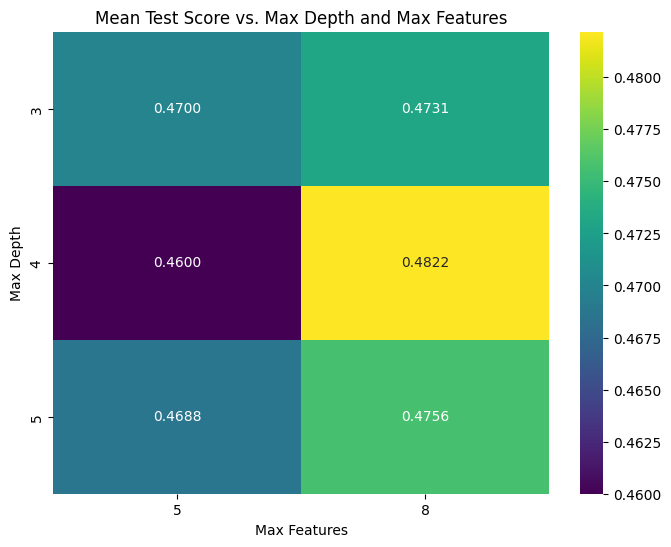

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns


results_df = results[['param_max_depth', 'param_max_features', 'mean_test_score']]
grouped_results = results_df.groupby(['param_max_depth', 'param_max_features']).mean().reset_index()
pivot_results = grouped_results.pivot(index='param_max_depth', columns='param_max_features', values='mean_test_score')

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_results, annot=True, cmap='viridis', fmt=".4f")
plt.title('Mean Test Score vs. Max Depth and Max Features')
plt.xlabel('Max Features')
plt.ylabel('Max Depth')
plt.show()

In [20]:
# making the final model using best parameters
model=RandomForestClassifier(**grid_search.best_params_)
model.fit(X_train,y_train)

RandomForestClassifier(max_depth=5, max_features=8, random_state=42)

In [21]:
print(f"Test set score: {model.score(X_test,y_test)}")

Test set score: 0.52


In [22]:
# classification report
from sklearn.metrics import classification_report
y_pred=model.predict(X_test)
print(f"Classification report: \n{classification_report(y_test,y_pred)}")

Classification report: 
              precision    recall  f1-score   support

           0       0.52      0.47      0.49       200
           1       0.52      0.57      0.55       200

    accuracy                           0.52       400
   macro avg       0.52      0.52      0.52       400
weighted avg       0.52      0.52      0.52       400



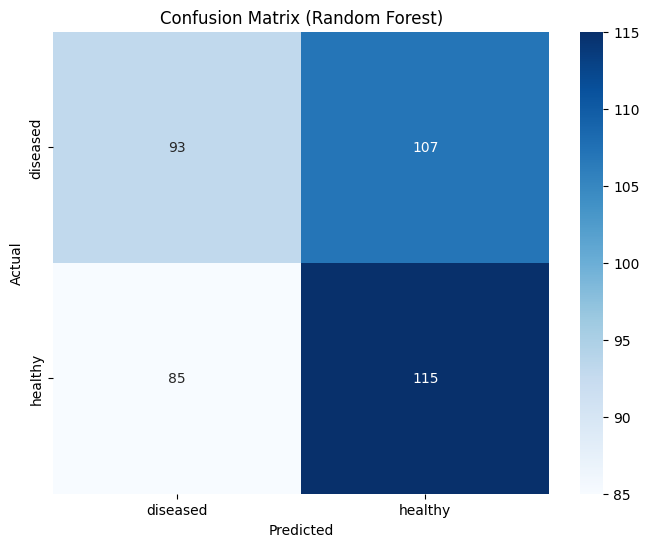

In [23]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['diseased', 'healthy'], yticklabels=['diseased', 'healthy'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest)')
plt.show()